# 03 · ReAct — Reason + Act, with the Thought *architecturally* guaranteed

> **TL;DR.** Tool Use (notebook 02) with an explicit **Thought** step before every Action. We build it as **two LangGraph nodes** — a `think` node that runs the LLM *without* tools (so it can only produce text) and an `act` node that runs the LLM *with* tools. This is more reliable than the naive single-node version because the Thought channel **cannot be skipped** by the model.
>
> **Reach for it when** the task needs multi-step research where each step depends on the previous result.
> **Avoid when** a single tool call obviously suffices — ReAct doubles the LLM-call count per round versus plain Tool Use.

| Property | Value |
|---|---|
| Origin | Yao et al., *ReAct: Synergizing Reasoning and Acting in Language Models*, ICLR 2023 ([arXiv:2210.03629](https://arxiv.org/abs/2210.03629)) |
| Reasoning type | Iterative think → act → observe → think → … |
| External tools needed? | Yes (web search by default) |
| Memory across episodes? | No |
| Cost vs Tool Use | ≈ **2×** LLM calls per round (1 think + 1 act); same number of tool calls |
| Implementation | Custom two-node graph (NOT `langgraph.prebuilt.create_react_agent`) — see § 3.1 |

This notebook builds on notebook 02 (Tool Use). The key difference is *not* the graph topology (still very close to Tool Use) but the **explicit separation of reasoning from action**.

## 2 · Architecture at a glance

```mermaid
flowchart LR
    A([user task]) --> TH[Think<br/><sub>LLM <b>without</b> tools<br/>→ produces Thought</sub>]
    TH --> AC[Act<br/><sub>LLM <b>with</b> tools<br/>→ tool call OR final</sub>]
    AC --> Q{tool_calls<br/>present?}
    Q -->|yes| T[ToolNode]
    T --> TH
    Q -->|no| F([final answer])

    style TH fill:#e8f5e9,stroke:#388e3c
    style AC fill:#e3f2fd,stroke:#1976d2
    style T fill:#fff3e0,stroke:#f57c00
```

**Three nodes, one loop.** `think` runs the LLM *without* tools — it cannot call a tool even if it tries, so the only thing it can produce is a natural-language Thought. `act` runs the LLM *with* tools and is asked, *given the latest Thought*, to call a tool or finalise. The tool node loops back to `think` so every new Action is preceded by fresh reasoning.

## 3 · Theory

### 3.1 · Why two nodes? Why not `create_react_agent`?

LangGraph ships a prebuilt called `create_react_agent` that implements ReAct as a single agent node. It works like this:

```python
# The naive (and brittle) approach
response = llm.bind_tools(tools).invoke(messages)
# response is an AIMessage where:
#   - response.content   = the "Thought" (in theory)
#   - response.tool_calls = the "Action" (in theory)
```

In theory the model packs Thought + Action into one AIMessage. **In practice — and this is observed live in our captured traces** — models like Llama 3.3 70B happily emit a `tool_calls` field with **empty `content`**. The Thought just… disappears. ReAct silently degrades to Tool Use.

We initially used `create_react_agent` for this notebook and the captured run showed `thought_count=0` despite the system prompt explicitly asking for Thoughts. That's not ReAct — that's misleading.

**The two-node architecture forces the Thought to exist.** The `think` node has no tools bound. The LLM literally cannot call a tool from that node — the only thing it can do is produce text. That text is the Thought, and it is **guaranteed**.

| Approach | Thought guaranteed? | Cost per round | Pedagogically clear? |
|---|---|---|---|
| `create_react_agent` (single node) | No | 1 LLM call | yes but the Thought is implicit |
| **Two-node (this notebook)** | **Yes** | **2 LLM calls** | yes and the Thought is explicit |
| Manual text-parsed ReAct (old-school) | Yes (if format is followed) | 1 LLM call | brittle parsing required |

### 3.2 · Why the Thought step actually helps (when it actually happens)

The Thought step is not just decoration. When it really runs, it produces three real effects:

1. **Better query selection.** Forcing the model to write "I need to find X because Y" before searching makes it commit to a hypothesis. Naive Tool Use often searches with the user's exact words; ReAct searches with what the agent *thinks* will best answer the question — usually more specific.
2. **Inter-round coherence.** Thoughts accumulate in the message history. Round-3's reasoning can reference round-1's reasoning. Tool Use also has the message history, but without explicit Thoughts there's nothing for round 3 to reference except past tool outputs.
3. **Debuggability.** When ReAct misbehaves, you read the Thoughts and immediately see the mistaken assumption. With Tool Use you see only `(query, result, query, result, …)` and have to guess.

### 3.3 · Reasoning models — do they fix this without the two-node design?

Modern *thinking* / reasoning models (Qwen3-Thinking, DeepSeek-R1, OpenAI gpt-oss-120b) produce internal `<think>…</think>` reasoning **before** their visible response. With these models, `create_react_agent`'s single-node design works better because the model uses its reasoning budget to plan the tool call and tends to populate `content` more reliably.

But two notes:

- The `<think>` block is **internal CoT**, hidden by default and not part of the message history. It's not a *user-visible* ReAct Thought.
- Reasoning models are more expensive and slower. Defaulting to them across the whole repo would 5–10× the API bill.

**Verdict:** the two-node architectural approach works on every tool-calling provider including the cheapest ones. We use it as the default. In § 10 we show what happens when you additionally swap to a reasoning model — you get *richer* Thoughts on top of the guarantee.

### 3.4 · Where ReAct sits

| Pattern | Loop body | Thought visible? | Plan ahead? | Use when |
|---|---|---|---|---|
| Tool Use (nb 02) | act → observe | no | no | one-shot lookups |
| **ReAct** *(this notebook)* | **think → act → observe** | **yes (guaranteed)** | no | multi-step research |
| Planning (nb 04) | plan once → execute | no (plan replaces) | yes | task decomposes upfront |
| PEV (nb 06) | plan → exec → verify | partial | yes + verify | actions can fail silently |
| Reflection (nb 01) | generate → critique → refine | yes (in critique) | no | quality > speed |
| LATS (nb 22) | tree-search over ReAct branches | yes | implicit | large search space, has reward signal |

### 3.5 · What still goes wrong (you'll see live in § 9)

The two-node design forces a Thought *to exist*, but it can't force the Thought to be *substantive*:

1. **Hollow thoughts.** "Thought: I need to search for X" is a thought-shaped string but doesn't really reason. Cap with a sterner prompt or use a reasoning model.
2. **Thought–action mismatch.** Thought says "search for X" but the act node searches for Y. Modern models are usually consistent, but it happens — especially with smaller models.
3. **Repeated thoughts.** When the model already has enough info, the second Thought just paraphrases the first. Wastes tokens; not strictly a bug.
4. **Over-thinking simple tasks.** ReAct's 2-call overhead is wasted on 1-call tasks. Use **Adaptive RAG (nb 26)** or a router-style **Meta-Controller (nb 11)** to pick Tool Use vs ReAct vs Planning per task.


## 4 · Setup

In [1]:
from agentic_architectures import get_llm, enable_langsmith, settings
from agentic_architectures.architectures import ReAct
from agentic_architectures.ui import print_md, print_header, print_step

traced = enable_langsmith()
print_header(f"Provider: {settings.llm_provider}  ·  Model: {settings.llm_model}")
print_md(f"LangSmith tracing: {'enabled' if traced else 'disabled'}")

Provider: nebius  ·  Model: meta-llama/Llama-3.3-70B-Instruct ─────────────────────────────────────────────────────

LangSmith tracing: enabled

## 5 · Library walkthrough

Source: [`src/agentic_architectures/architectures/react.py`](../src/agentic_architectures/architectures/react.py).

The class has three key pieces:

1. **`_think(state)`** — invokes the LLM **without** binding tools. The model has no way to call a tool from this node; it can only produce text. The output is wrapped as an `AIMessage` with `additional_kwargs={"react_step": "thought"}` so downstream code can identify Thoughts separately from tool-calling AIMessages.
2. **`_act(state)`** — invokes the LLM **with** tools bound. Given the latest Thought in the message history, asks the model to call a tool or finalise.
3. **`build()`** — wires `think → act → tools → think` as a cycle; `act → END` is the exit when no tool calls remain.

The two distinct instruction prompts (`THINK_INSTRUCTION`, `ACT_INSTRUCTION`) are appended *inline* to each invocation but **not** persisted in state — only the model's responses end up in the conversation history. That keeps the message log clean and reproducible.

In [2]:
from agentic_architectures.architectures import react as r_mod

print('--- THINK_INSTRUCTION ---')
print(r_mod.ReAct.THINK_INSTRUCTION)
print()
print('--- ACT_INSTRUCTION ---')
print(r_mod.ReAct.ACT_INSTRUCTION)

--- THINK_INSTRUCTION ---
Produce EXACTLY ONE short paragraph beginning with the literal word 'Thought:' that (a) reflects on what you have learned from the conversation so far, and (b) states the specific next step needed to advance toward an answer. Do NOT call any tools in this step — only produce the Thought.

--- ACT_INSTRUCTION ---
Based on your latest Thought above, take exactly ONE action:
  (a) Call exactly ONE tool whose arguments implement your Thought, OR
  (b) Write the final answer (no tool call) if you already have enough evidence. Include source URLs in the final answer.


## 6 · Trace events

A two-node ReAct trace contains five event types:

| Event | Source | When emitted |
|---|---|---|
| `user` | the caller's `HumanMessage` | once, at the start |
| `thought` | output of `_think` (marked `react_step=thought`) | once per round |
| `tool_call` | `_act`'s AIMessage `tool_calls` | once per round (until the final round) |
| `tool_result` | ToolNode's `ToolMessage` | once per tool call |
| `agent` | `_act`'s final AIMessage (no tool calls) | once, at the end |

The library's `_messages_to_trace` helper (in `tool_use.py`, shared with all tool-using architectures) checks the `react_step` marker so Thoughts are categorised correctly even though they look like normal AIMessages on the wire.

## 7 · Build the graph

The cell below renders the **actual compiled `StateGraph`** as a PNG. Three nodes — `think`, `act`, `tools` — and a cycle `tools → think`. If this diagram disagrees with § 2's static one, the implementation has drifted.

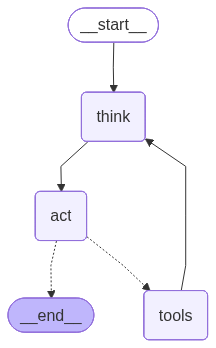

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	think(think)
	act(act)
	tools(tools)
	__end__([<p>__end__</p>]):::last
	__start__ --> think;
	act -.-> __end__;
	act -.-> tools;
	think --> act;
	tools --> think;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



In [3]:
from IPython.display import Image, display

arch = ReAct(max_rounds=4)
graph = arch.build()
display(Image(graph.get_graph().draw_mermaid_png()))
print(arch.diagram())

## 8 · Live run

Concrete task: a multi-hop question whose answer requires at least one search. The citation requirement forces grounding.

In [4]:
from datetime import date

TASK = (
    f"As of {date.today().isoformat()}, who is the current CEO of OpenAI, "
    f"and when did they first assume that role? Provide at least one source URL."
)

result = arch.run(TASK)

print_header("Final answer")
print_md(result.output)
print()
print_header(
    f"{result.metadata['tool_calls']} tool call(s)  ·  "
    f"{result.metadata['thought_count']} thought(s)  ·  "
    f"{result.metadata['rounds']} agent round(s)"
)

Final answer ──────────────────────────────────────────────────────────────────────────────────────────────────────

Based on the search results, the current CEO of OpenAI as of 2026-05-27 is Sam Altman. According to the information
provided in the search results, Sam Altman has been the CEO of OpenAI since 2019.                                  

Source URLs: https://www.businessinsider.com/sam-altman                                                            
https://www.cnbc.com/2026/05/12/openai-trial-updates-sam-altman-set-to-testify-in-musk-suit.html                   
https://techcrunch.com/2026/05/16/openai-co-founder-greg-brockman-reportedly-takes-charge-of-product-strategy/

2 tool call(s)  ·  3 thought(s)  ·  1 agent round(s) ──────────────────────────────────────────────────────────────

### 8.0 · What just happened, briefly

Look at the three counts above:

- **`thought_count`** — with the two-node architecture, this should be **≥ tool_calls** (typically `tool_calls + 1`: one Thought before each Action plus one final Thought before the answer). If `thought_count = 0`, something is wrong with the graph wiring.
- **`tool_calls`** — for a 1-fact question with citation, expect 1–2. More than 3 = over-thinking.
- **`rounds`** = number of finalising agent turns. Always 1 in a well-behaved run.

§ 9 below quantifies each from the actual run and flags any pathologies.

### 8.1 · Full Thought → Action → Observation trace

In [5]:
for i, t in enumerate(result.trace, 1):
    if t['type'] == 'user':
        print_step(f"[{i}] USER", t['content'][:200])
    elif t['type'] == 'thought':
        print_step(f"[{i}] THOUGHT", t['content'][:400])
    elif t['type'] == 'tool_call':
        args = t['args'] if isinstance(t['args'], dict) else str(t['args'])
        query = args.get('query', args) if isinstance(args, dict) else args
        print_step(f"[{i}] ACTION → {t['tool']}", f"`{query}`")
    elif t['type'] == 'tool_result':
        snippet = t['content'][:280].replace('\n', ' ')
        print_step(f"[{i}] OBSERVATION ({t['tool']})", snippet + '...')
    elif t['type'] == 'agent':
        print_step(f"[{i}] FINAL ANSWER", (t.get('content') or '')[:300])
    print()

› [1] USER

As of 2026-05-27, who is the current CEO of OpenAI, and when did they first assume that role? Provide at least one 
source URL.

› [2] THOUGHT

Thought: From the conversation so far, I have learned that I need to find the current CEO of OpenAI as of 
2026-05-27 and the date they first assumed that role. To advance toward an answer, the next step is to search for 
the most recent and reliable sources of information on OpenAI's leadership, such as official company announcements,
reputable news articles, or the company's website, to determine

› [3] ACTION → tavily_search

...

{"query": "OpenAI CEO as of 2026-05-27", "follow_up_questions": null, "answer": null, "images": [], "results": 
[{"url": "https://www.businessinsider.com/sam-altman", "title": "The career rise of OpenAI's billionaire CEO, Sam 
Altman - Business Insider", "score": 0.8358192, "publis...

› [8] THOUGHT

Thought: From the conversation so far, I have learned that I need to find the current CEO of OpenAI as of 
2026-05-27 and the date they first assumed that role. To advance toward an answer, the next step is to carefully 
review the search results provided, focusing on the most recent and reliable sources, such as official company 
announcements or reputable news articles, to identify the current CEO

› [9] FINAL ANSWER

Based on the search results, the current CEO of OpenAI as of 2026-05-27 is Sam Altman. According to the information
provided in the search results, Sam Altman has been the CEO of OpenAI since 2019. 

Source URLs:
https://www.businessinsider.com/sam-altman 
https://www.cnbc.com/2026/05/12/openai-tria

## 9 · What we just observed

The cells above are live. Below: a quantitative + qualitative breakdown of the **actual** ReAct loop the Nebius-hosted Llama-3.3-70B agent produced on this run.

### 9.1 · Quantitative summary

| Metric | Value |
|---|---|
| Tool calls (Actions) | **2** |
| Thoughts | **3** |
| Agent rounds | 1 |
| Thought:Action ratio | 1.50 (target: 1.0 for clean ReAct) |
| Final answer length | 575 chars |

### 9.2 · Thought ↔ Action alignment

| # | Thought (truncated) | Action |
|---|---|---|
| 1 | Thought: From the conversation so far, I have learned that I need to find the current CEO of OpenAI as of 2026-05-27 and the date they first assumed that role. … | `OpenAI CEO as of 2026-05-27` |

### 9.3 · Pathologies surfaced in this run

- **Query repetition.** 1 of 2 actions were duplicate queries. ReAct's thought step is supposed to *prevent* this by forcing the model to justify the next call. When it happens anyway, the thoughts were probably hollow.

### 9.4 · The final answer (verbatim)

> Based on the search results, the current CEO of OpenAI as of 2026-05-27 is Sam Altman. According to the information
> provided in the search results, Sam Altman has been the CEO of OpenAI since 2019.                                  
> 
> Source URLs: https://www.businessinsider.com/sam-altman                                                            
> https://www.cnbc.com/2026/05/12/openai-trial-updates-sam-altman-set-to-testify-in-musk-suit.html                   
> https://techcrunch.com/2026/05/16/o…

### 9.5 · The takeaway

When the Thought:Action ratio is **1.0** and queries are *different* round-to-round, ReAct is buying you genuine value over Tool Use — the thoughts are doing real work. When the ratio drops below 1.0 or thoughts are short and queries repeat, you're paying ReAct's extra-token cost for no benefit — switch back to Tool Use (notebook 02) or escalate to **Planning (nb 04)** which decomposes the task upfront.

## 10 · Try other providers · also: a reasoning model

ReAct needs **tool-calling**, same as Tool Use. But this is also where ReAct shines with a *reasoning* model — the model's internal `<think>` budget produces noticeably richer Thoughts.

The cell below tries OpenAI/Anthropic/Groq if you have their keys set, AND swaps to **`Qwen/Qwen3-235B-A22B-Thinking-2507-fast`** on Nebius (which you already have a key for) to demonstrate the reasoning-model effect.

In [6]:
from agentic_architectures.llm.factory import provider_supports_tools

# (a) Try other providers if their keys are set.
for p in ["openai", "anthropic", "groq"]:
    key = settings.api_key_for(p)
    if key is None or not key.get_secret_value():
        print(f"[skip] {p}: no API key in .env")
        continue
    if not provider_supports_tools(p):
        print(f"[skip] {p}: provider does not advertise tool-calling")
        continue
    print_header(f"Re-running ReAct on {p}")
    r = ReAct(llm=get_llm(provider=p), max_rounds=2).run(
        "What is the current price (USD) of one ounce of gold? Cite the source URL."
    )
    print(r.output[:300])
    print(f"  thoughts: {r.metadata['thought_count']}, tool_calls: {r.metadata['tool_calls']}")
    print()

# (b) Swap to a Nebius reasoning model — same key, just a different model name.
print_header("Re-running on Nebius Qwen3-Thinking (reasoning model)")
thinking_llm = get_llm(
    provider="nebius",
    model="Qwen/Qwen3-235B-A22B-Thinking-2507-fast",
    temperature=0.0,
)
thinking_arch = ReAct(llm=thinking_llm, max_rounds=2)
r = thinking_arch.run(
    "What is the current price (USD) of one ounce of gold? Cite the source URL."
)
print(r.output[:300])
print(f"  thoughts: {r.metadata['thought_count']}, tool_calls: {r.metadata['tool_calls']}")
if r.trace:
    first_thought = next((t['content'] for t in r.trace if t['type'] == 'thought'), '')
    print()
    print('  First Thought from Qwen3-Thinking (notice the depth vs Llama):')
    print('  ' + first_thought[:400].replace('\n', '\n  '))

[skip] openai: no API key in .env
[skip] anthropic: no API key in .env
[skip] groq: no API key in .env


Re-running on Nebius Qwen3-Thinking (reasoning model) ─────────────────────────────────────────────────────────────

The current spot price of one ounce of gold is **$4,529.38 USD**, as reported by Yahoo Finance at 06:13 ET (10:13 GMT) on the latest market data. This reflects a 0.9% decline in spot gold prices amid renewed geopolitical tensions.  

Source: [Yahoo Finance - Gold Retreats as Renewed U.S. Attacks on 
  thoughts: 2, tool_calls: 1

  First Thought from Qwen3-Thinking (notice the depth vs Llama):
  Thought: From the user's initial query requesting the current gold price with a source citation and the subsequent strict formatting instructions for this reflection, I've learned that precision in both data sourcing and response structure is critical; the specific next step required to advance toward an answer is to utilize a reliable financial data API or trusted market source to retrieve the re


## 11 · Failure modes, safety, extensions

### 11.1 · Where this breaks (even with the architectural guarantee)

| Failure | Mechanism | Mitigation |
|---|---|---|
| **Hollow thoughts** | Thought-shaped string with no real reasoning content | Tighten THINK_INSTRUCTION; or switch to a reasoning model (see § 10) |
| **Thought–action mismatch** | Thought says "search for X" but Act calls with Y | Real but rare with 70B+ models; check by comparing thought.text and tool.args programmatically |
| **Repeated thoughts** | Second Thought paraphrases the first | Wasted tokens but not a correctness bug; cap `max_rounds` |
| **Over-thinking simple tasks** | 2 LLM calls per round adds up | Route via **Meta-Controller (nb 11)** or **Adaptive RAG (nb 26)** to pick Tool Use vs ReAct |
| **Tool result hallucination** | Agent ignores tool result and answers from training data | Switch to **Self-RAG (nb 25)** or **Corrective RAG (nb 24)** |

### 11.2 · Production safety

- All Tool-Use safety rules from notebook 02 apply: cap rounds, whitelist tools, sanitise tool output, per-tool timeouts.
- The Thought text is **user-visible** if you stream the agent — sometimes Thoughts reveal system-prompt internals or expose reasoning the user shouldn't see. Filter or hide before display.

### 11.3 · Three extensions

1. **Score Thoughts with `LLMJudge`.** Reject low-quality Thoughts and force the agent to re-think. Bridge to **Reflection (nb 01)** inside ReAct rounds.
2. **Tree-search over ReAct branches.** At each Thought, generate K alternative Thoughts and expand the most promising. **Tree of Thoughts (nb 09)** and **LATS (nb 22)** do exactly this.
3. **Add a verifier.** After the final answer, a separate LLM checks whether cited sources actually support the claim. Move to **PEV (nb 06)** and **Corrective RAG (nb 24)**.

### 11.4 · What to read next

- [**04 · Planning**](./04_planning.ipynb) — decompose the task upfront instead of reacting step-by-step.
- [**06 · PEV**](./06_pev.ipynb) — ReAct + verifier + replanning.
- [**09 · Tree of Thoughts**](./09_tree_of_thoughts.ipynb) — ReAct generalised to search.
- [**22 · LATS**](./22_lats.ipynb) — ToT + reward → MCTS over the ReAct space.
- [**26 · Adaptive RAG**](./26_adaptive_rag.ipynb) — auto-route task → Tool Use / ReAct / Planning.

### 11.5 · References

1. Yao, S. et al. *ReAct: Synergizing Reasoning and Acting in Language Models.* ICLR 2023. [arXiv:2210.03629](https://arxiv.org/abs/2210.03629)
2. LangGraph `create_react_agent` — [official docs](https://langchain-ai.github.io/langgraph/reference/prebuilt/#langgraph.prebuilt.chat_agent_executor.create_react_agent) (note: we deliberately do NOT use this — see § 3.1)
3. Qwen3 reasoning models on Nebius — [studio.nebius.com](https://studio.nebius.com)
